In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

## **Data Loading** ##

In [5]:
df = pd.read_csv('hand_landmarks_data.csv')
df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

In [7]:
df.describe()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,z18,x19,y19,z19,x20,y20,z20,x21,y21,z21
count,25675.000000,25675.000000,2.567500e+04,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,...,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000
mean,201.958632,260.158527,1.272461e-07,202.517395,252.115322,-0.009465,202.862981,240.645966,-0.015946,203.025267,...,-0.024129,201.792374,227.455597,-0.033751,201.811275,227.802576,-0.032208,201.874802,227.807287,-0.028828
std,90.500333,76.533210,2.737932e-07,84.770933,75.384691,0.010376,80.412089,74.721921,0.013973,79.647588,...,0.015658,94.046497,77.231210,0.020453,93.664595,78.441253,0.020877,93.547017,79.963438,0.021136
min,-36.050926,45.722923,-2.029986e-06,7.184681,51.256840,-0.096630,25.114323,45.489950,-0.155846,23.446341,...,-0.201897,0.198635,20.146784,-0.286821,3.278137,32.158108,-0.286470,-4.537216,23.226204,-0.262047
25%,124.110329,205.815950,-5.243216e-08,130.535929,197.999625,-0.015199,136.711035,187.018583,-0.023020,138.905817,...,-0.030728,126.828913,172.720392,-0.042726,126.887403,172.345467,-0.041957,126.356627,172.083794,-0.039220
50%,199.667847,255.181793,1.497277e-07,199.979530,247.113892,-0.008737,200.092758,235.776978,-0.014231,200.482040,...,-0.020969,197.579865,221.781479,-0.029942,197.591736,222.381149,-0.028510,197.453270,222.485229,-0.025269
75%,266.428482,304.991663,2.989988e-07,261.147457,296.850769,-0.002783,255.876354,284.925993,-0.007134,254.622768,...,-0.013661,268.103920,273.190765,-0.019987,267.745743,274.196884,-0.017971,267.324657,275.805222,-0.014294
max,633.556020,781.674469,1.876254e-06,606.232386,751.869416,0.076365,598.541348,719.365010,0.094131,607.999801,...,0.031774,632.923029,779.419948,0.078105,638.134761,760.854103,0.104580,641.788521,760.554894,0.118668


In [20]:
df.shape

(25675, 64)

In [21]:
df['label'].value_counts()

label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945
Name: count, dtype: int64

## **Data Visulaization** 

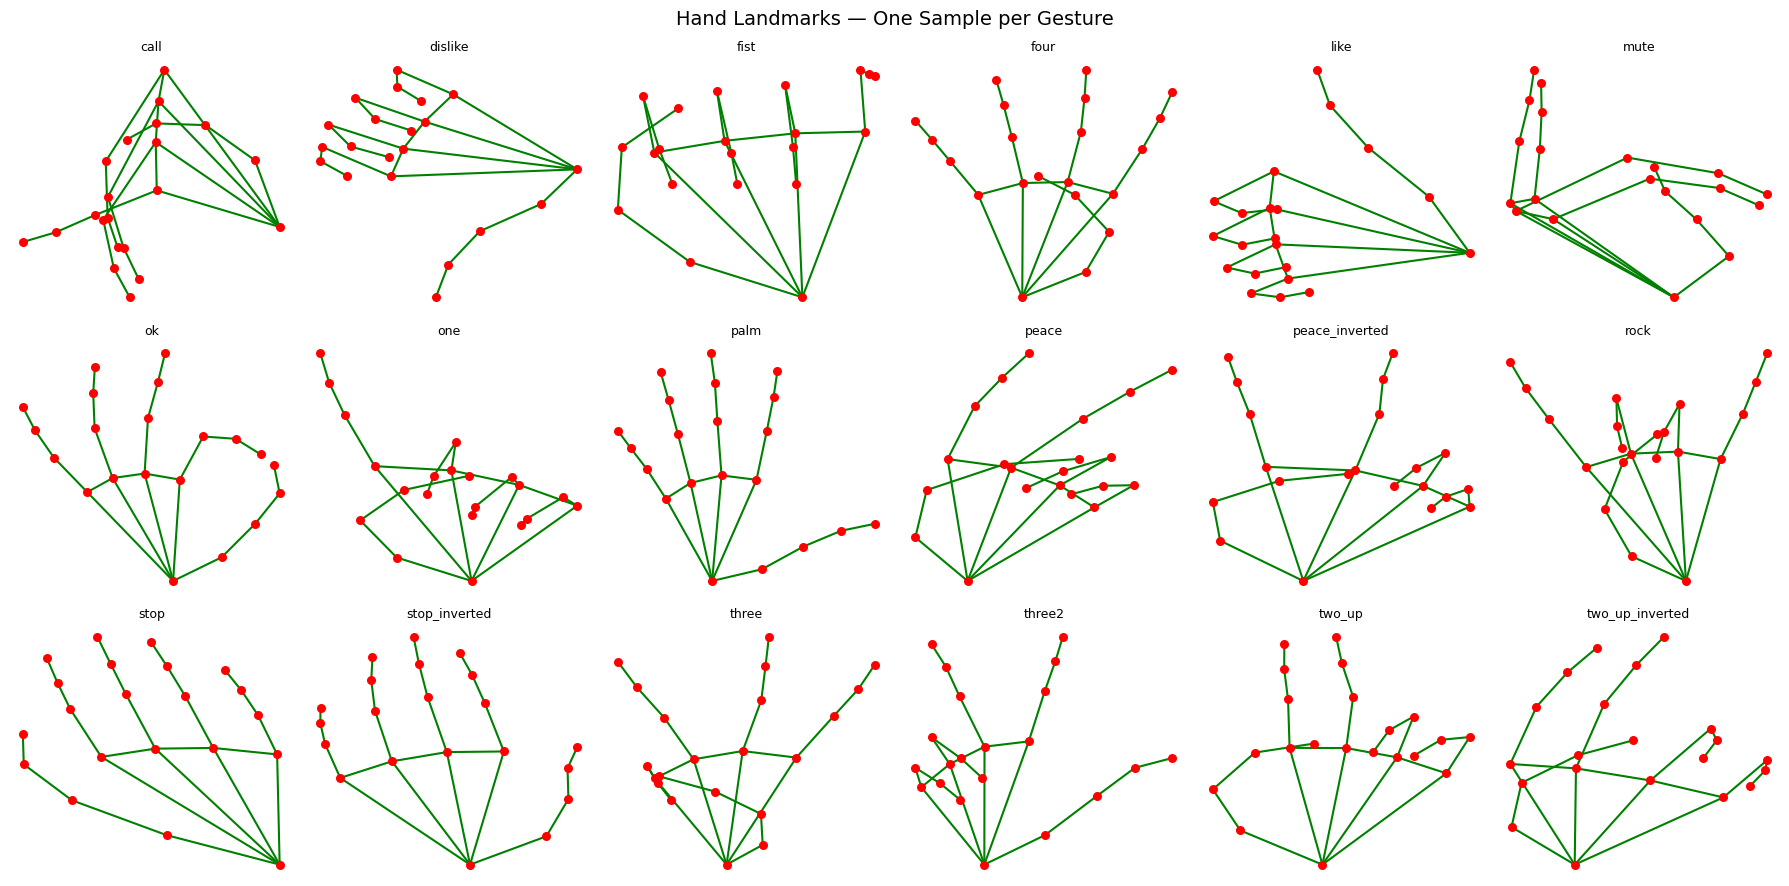

In [22]:
# MediaPipe hand connections (which landmarks to connect with lines)
connections = [
    (0,1),(1,2),(2,3),(3,4),        # Thumb
    (0,5),(5,6),(6,7),(7,8),        # Index
    (0,9),(9,10),(10,11),(11,12),   # Middle
    (0,13),(13,14),(14,15),(15,16), # Ring
    (0,17),(17,18),(18,19),(19,20), # Pinky
    (5,9),(9,13),(13,17)            # Palm
]

classes = df['label'].unique()

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()

for i, gesture in enumerate(sorted(classes)):
    # Get one sample from this gesture class
    row = df[df['label'] == gesture].iloc[0]

    # Get x and y coordinates (landmarks 1 to 21)
    x = [row[f'x{j}'] for j in range(1, 22)]
    y = [row[f'y{j}'] for j in range(1, 22)]

    ax = axes[i]

    # Draw skeleton lines
    for start, end in connections:
        ax.plot([x[start], x[end]], [y[start], y[end]], 'g-', linewidth=1.5)

    # Draw keypoints
    ax.scatter(x, y, c='red', s=30, zorder=5)

    ax.set_title(gesture, fontsize=9)
    ax.invert_yaxis()
    ax.axis('off')

plt.suptitle('Hand Landmarks — One Sample per Gesture', fontsize=14)
plt.tight_layout()
plt.show()


## **Data Preprocessing**

#### Handling null values 

In [23]:
df.isna().sum()

x1       0
y1       0
z1       0
x2       0
y2       0
        ..
z20      0
x21      0
y21      0
z21      0
label    0
Length: 64, dtype: int64

In [25]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")

# Drop rows with missing values (if any)
df = df.dropna()
print("Shape after dropping nulls:", df.shape)


Missing values per column:
0 total missing values
Shape after dropping nulls: (25675, 64)


#### Handling the duplicated values 

In [24]:
df.duplicated().sum()

np.int64(0)

#### Normalize landmarks 

In [26]:
df_normalized = df.copy()

In [32]:
for i, row in df.iterrows():
    wrist_x = row['x1']
    wrist_y = row['y1']
    
    for j in range(1,22):
        
        df_normalized.at[i,f'x{j}'] = row[f'x{j}'] - wrist_x
        df_normalized.at[i,f'y{j}'] = row[f'y{j}'] - wrist_y
        
    mid_x = df_normalized.at[i, 'x13']
    mid_y = df_normalized.at[i, 'y13']
    
    for j in range(1,22):
        if mid_x != 0:
            df_normalized.at[i,f'x{j}'] = df_normalized.at[i,f'x{j}'] / mid_x
        if mid_y != 0:
            df_normalized.at[i,f'y{j}'] = df_normalized.at[i,f'y{j}'] / mid_y
                

#### Encoding labels 

In [34]:
le = LabelEncoder()

df_normalized['label_encoded'] = le.fit_transform(df_normalized['label'])

In [35]:
print("Classes : " ,list(le.classes_))

Classes :  ['call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one', 'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted', 'three', 'three2', 'two_up', 'two_up_inverted']


In [38]:
print("Encoded as:", list(range(len(le.classes_))))

Encoded as: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


#### Split Features and target 

In [40]:
feature_cols = [f'x{i}' for i in range(1, 22)] + \
               [f'y{i}' for i in range(1, 22)] + \
               [f'z{i}' for i in range(1, 22)]

X = df_normalized[feature_cols]
y = df_normalized['label_encoded']

print("Features shape:", X.shape)
print("Labels shape:", y.shape)


Features shape: (25675, 63)
Labels shape: (25675,)


#### Train / Test split 

In [41]:
print("length of data " , len(df_normalized))

length of data  25675


In [42]:
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.2, random_state=42 ,stratify=y)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (20540, 63) (20540,)
Testing set shape: (5135, 63) (5135,)
